Calculando 10000 dígitos de sqrt(2)...


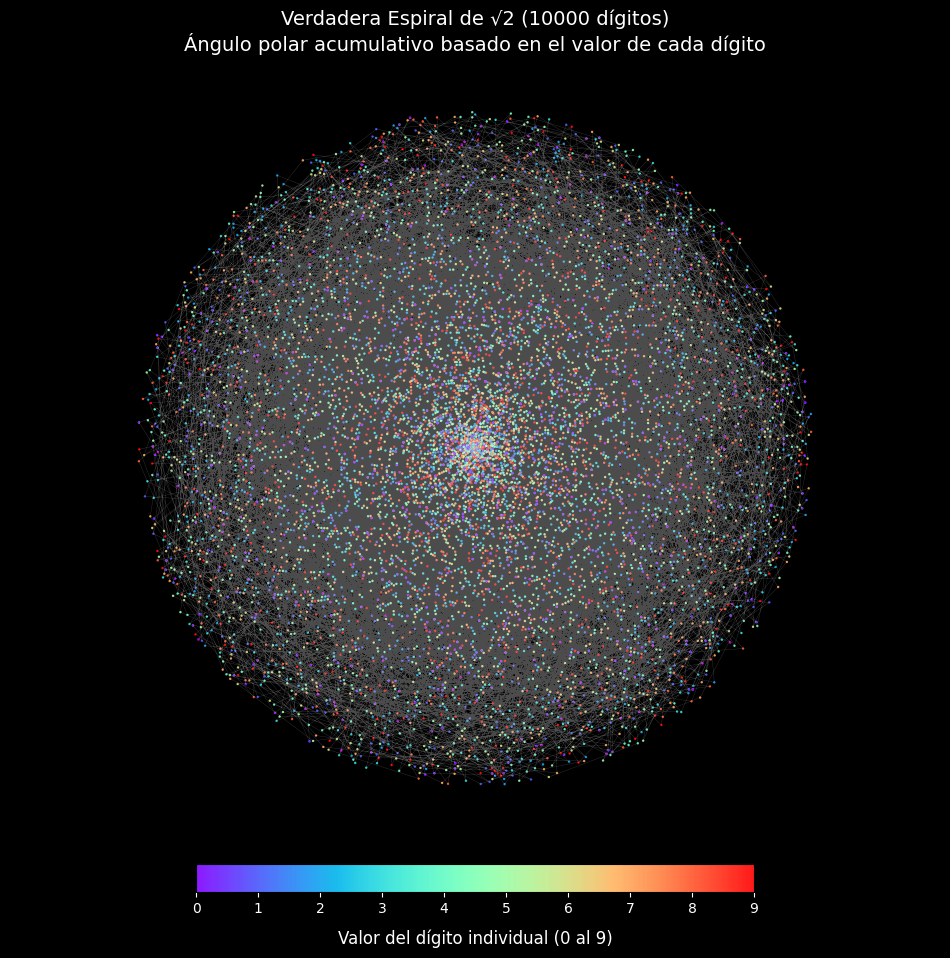

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from mpmath import mp

# --- CONFIGURACIÓN ---
CANTIDAD_DIGITOS = 10000  # Puedes subirlo a 50000 para ver más vueltas de la espiral
mp.dps = CANTIDAD_DIGITOS + 5

print(f"Calculando {CANTIDAD_DIGITOS} dígitos de sqrt(2)...")

# Obtener los dígitos de sqrt(2) limpios
sqrt2_str = str(mp.sqrt(2)).replace('.', '')
digitos_str = sqrt2_str[:CANTIDAD_DIGITOS]
digitos = np.array([int(d) for d in digitos_str])

# --- NUEVA LÓGICA DE ESPIRAL ACUMULATIVA ---
# El radio crece secuencialmente (0, 1, 2, 3...) para ir hacia afuera
r = np.arange(CANTIDAD_DIGITOS)

# El ángulo es la SUMA ACUMULADA de los dígitos.
# Restamos el primer dígito para que empiece exactamente en 0 como me indicaste.
theta = np.cumsum(digitos) - digitos[0]

# Convertimos las coordenadas polares acumulativas a cartesianas (x, y)
# Nota: Dejamos theta en radianes puros para que mantenga la naturaleza matemática de la espiral
x = r * np.cos(theta)
y = r * np.sin(theta)

# --- VISUALIZACIÓN ---
plt.figure(figsize=(12, 12), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Graficamos los puntos y los conectamos con una línea muy fina para ver el camino de la espiral
plt.plot(x, y, color='white', linewidth=0.2, alpha=0.3)
scatter = plt.scatter(x, y, c=digitos, cmap='rainbow', s=3, alpha=0.9, edgecolors='none')

# Configuración estética
plt.title(f"Verdadera Espiral de √2 ({CANTIDAD_DIGITOS} dígitos)\nÁngulo polar acumulativo basado en el valor de cada dígito",
          color='white', fontsize=14, pad=20)
plt.axis('equal')
plt.axis('off')

# Barra de color para identificar el dígito individual de cada punto
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
cbar.set_label('Valor del dígito individual (0 al 9)', color='white', fontsize=12, labelpad=10)
cbar.ax.xaxis.set_tick_params(color='white', labelcolor='white')

plt.show()
